# Deformation of plate based on linear elasticity

This notebook implements the linear elasticity equations where Young's modulus is uncertain and sampled from a log-normal-like distribution. Dependencies are mentioned in the `neuralop.yml` file in the root directory of this repository.

## Problem description

Consider a two dimensional domain $D_u = (0, 1) \times (0, 1) \subset \mathbb{R}^2$. Suppose $m(x)$ denotes the Young's modulus field, $u = (u_1, u_2): D_u \to \mathbb{R}^2$ denotes the displacement field, $e(x) = (\nabla u + \nabla u^T)/2$ denotes the linearized strain, and $\sigma(x)$ denotes the Cauchy stress. The governing equations read
\begin{equation}\tag{1}
    \begin{aligned}
        -\nabla \cdot \sigma(x) &= b(x)\,, \qquad & &\forall x\in D_u\,,\\
        \sigma(x) &= \lambda(x) \mathrm{tr}(e) \mathrm{I} + 2\mu(x) e\,, \qquad & & \forall x \in D_u\,,\\
        u(x) &= 0\,,\qquad & & \forall x\in \Gamma_{u_d}\,,\\
        \sigma(x) n(x) &= t(x)\,, \qquad & & \forall x\in \Gamma_{u_q} = \partial D_u - \Gamma_{u_d}\,,
    \end{aligned}
\end{equation}
where $\mathrm{tr}(e) = e_{11} + e_{22}$, $\mathrm{I}$ is the identity second-order tensor, and $\lambda$ and $\mu$ are Lam\'e parameters related to $m$ and Poisson ratio $\nu$ as
\begin{equation}\tag{2}
    \lambda(x) = \frac{m(x) \nu}{(1+\nu)(1-2\nu)} \quad \text{and} \quad \mu(x) = \frac{m(x)}{2(1+\nu)}\,.
\end{equation}
In Eq. (1), $\Gamma_{u_d} := \left\{x\in \partial D_u: x_1 = 0 \right\}$, $\Gamma_{u_q} := \partial D_u - \Gamma_{u_d}$, $n$ is the unit outward normal, and $t$ is the specified traction. We fix $\nu = 0.45$ and
\begin{equation}\tag{3}
     b(x) = 0\hat{e}_1 + 0 \hat{e}_2 \quad \text{and} \quad t(x) = 20\hat{e}_1 + 50 \hat{e}_2\,.
\end{equation}

The probability distribution for $m$ is given by
\begin{equation}\tag{4}
    m = \alpha_m \exp(w) + \beta_m, \qquad \text{where} \quad w \sim N(0, C)\,,
\end{equation}
where $N(0, C)$ denotes the Gaussian measure with the mean function being zero in $L^2(\Omega, \mathbb{R})$ and $C: L^2(\Omega; \mathbb{R}) \times L^2(\Omega; \mathbb{R})\to \mathbb{R}$ is a covariance operator such that $C = L_\Delta^{-2}$, where
\begin{equation}\tag{5}
    L_\Delta := \begin{cases}
        -\mathsf{a}_c \nabla \cdot \mathsf{b}_c \nabla + \mathsf{c}_c\,, \qquad\qquad  &  \text{in } D_w\,,\\
        \mathsf{a}_c n \cdot \mathsf{b}_c \nabla\,, \qquad \qquad & \text{on }\partial D_w\,,
    \end{cases}
\end{equation}
with $\mathsf{a}_c, \mathsf{b}_c, \mathsf{c}_c$ are the parameters and there values including $\alpha_m$ and $\beta_m$ are fixed to
\begin{equation}\tag{6}
\mathsf{a}_c = 0.005\,, \quad \mathsf{b}_c = 1\,, \quad \mathsf{c}_c = 0.2\,,\quad \alpha_m = 100\,, \quad \beta_m = 1000\,.
\end{equation}

Given $m\in M$, we let $F(m) = u\in U$ be the solution of boundary value problem (BVP) Eq. (1), i.e., $F: M \to U$ is the solution/forward operator.

## Random samples of m and corresponding solution u(m)

<p align="center"> <img src="./data/LinearElasticity_sample_plots.png" width="600"> </p>


In [1]:
import sys
import time
import os

import matplotlib.pyplot as plt
import numpy as np
from dolfinx import mesh
from dolfinx.fem import functionspace
from dolfinx.mesh import CellType
from mpi4py import MPI
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import RegularGridInterpolator, griddata

NOTEBOOK_DIR = os.getcwd()
ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..', '..'))
sys.path.insert(0, os.path.join(ROOT, 'src/plotting'))
sys.path.insert(0, os.path.join(ROOT, 'src/prior'))
sys.path.insert(0, os.path.join(ROOT, 'src/pde'))
sys.path.insert(0, NOTEBOOK_DIR)

from field_plot import field_plot, field_plot_grid, quick_field_plot, quick_field_plot_grid
from meshUtilities import (
    apply_grid_vector_dirichlet_bc,
    get_dirichlet_bc,
    get_grid_dirichlet_bc,
    interpolate_mixed_vector_to_grid,
    mesh_cells,
    write_mesh_xdmf,
)
from plot_mix_collection import *
from plot_svd import plot_s_vec_values
from linearElasticityModel import LinearElasticityModel
from priorSampler import PriorSampler

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

seed = 0
np.random.seed(seed)


In [2]:
data_folder = 'data/'
current_directory = os.getcwd()  
results_dir = current_directory + '/' + data_folder
if not os.path.exists(results_dir):
    os.makedirs(results_dir)


# Create LinearElasticityModel and test prior

In [3]:
prior_ac = 0.005
prior_cc = 0.2
prior_logn_scale = 100.
prior_logn_translate = 1000.
nx, ny = 50, 50
fe_order = 1
data_prefix = 'LinearElasticity'

domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, cell_type=CellType.triangle)
Vm = functionspace(domain, ("Lagrange", fe_order))
Vu = functionspace(domain, ("Lagrange", fe_order, (2,)))

prior_sampler = PriorSampler(Vm, prior_ac, prior_cc, seed)
model = LinearElasticityModel(Vm, Vu, prior_sampler, prior_logn_scale, prior_logn_translate, seed)
nodes = model.m_nodes
print(f"m_dim={model.m_dim}, u_dim={model.u_dim}, nodes.shape={nodes.shape}")


m_dim=2601, u_dim=5202, nodes.shape=(2601, 2)


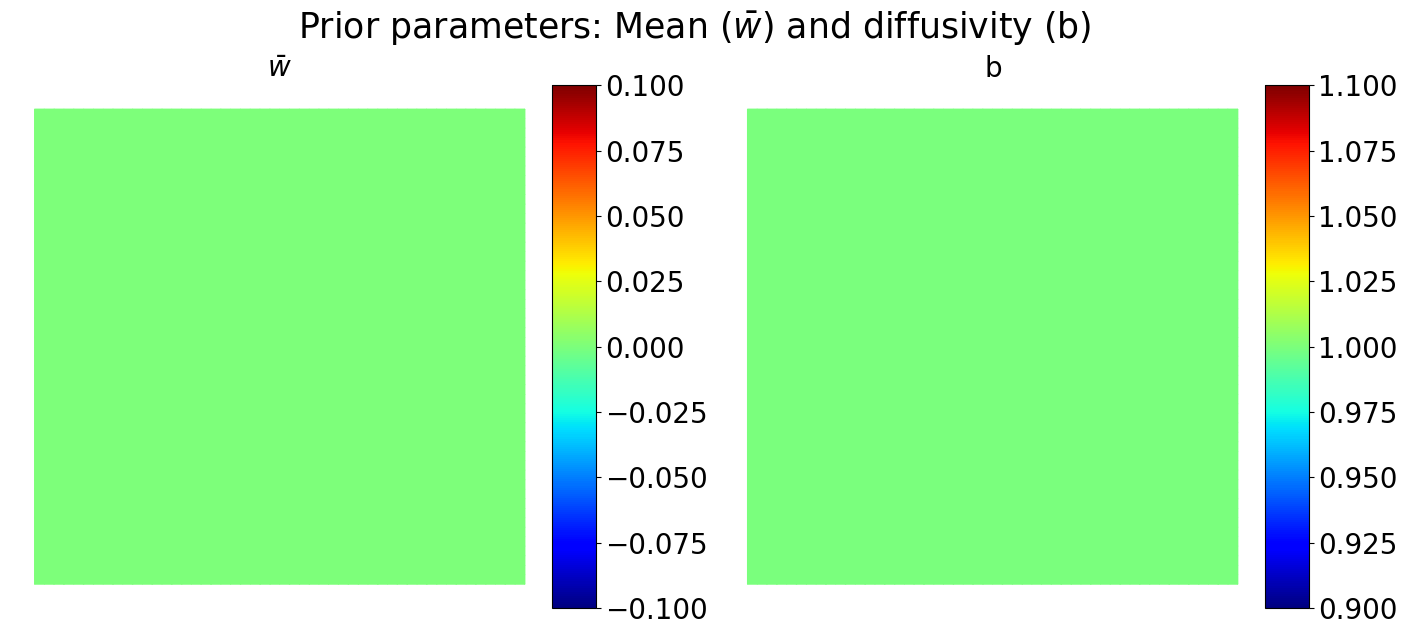

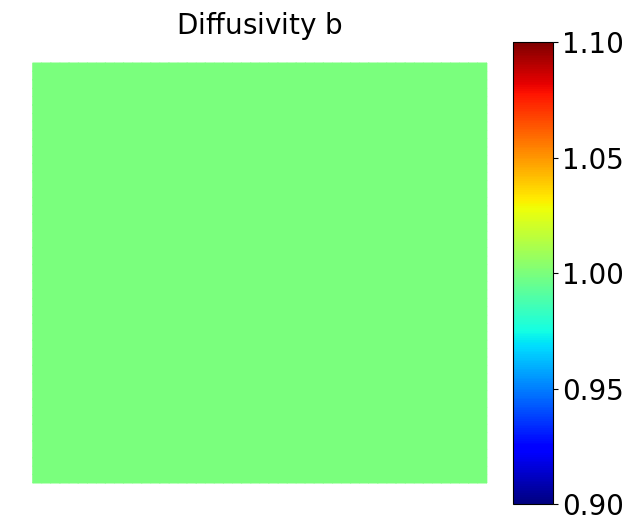

In [4]:
fs = 20
rows, cols = 1, 2
fig, axs = plt.subplots(rows, cols, figsize=(14, 6))
axs = np.atleast_1d(axs).reshape(rows, cols)
stats = []
m = prior_sampler.empty_sample()

for i in range(rows):
    for j in range(cols):
        
        m = prior_sampler.mean if j == 0 else prior_sampler.function_to_vertex(prior_sampler.b_fn, None)
        # plot
        cbar = field_plot(axs[i,j], \
                  m, \
                  nodes, cmap = 'jet')
        divider = make_axes_locatable(axs[i,j])
        cax = divider.append_axes('right', size='8%', pad=0.03)
        cax.tick_params(labelsize=fs)
        cbar = fig.colorbar(cbar, cax=cax, orientation='vertical')

        axs[i,j].set_title(r'$\bar{w}$' if j == 0 else r'$\mathsf{b}$', fontsize=fs)
        axs[i,j].axis('off')

fig.tight_layout()
fig.suptitle(r'Prior parameters: Mean ($\bar{w}$) and diffusivity ($\mathsf{b}$)', fontsize=1.25*fs, y = 1.05)
plt.savefig(results_dir + 'prior_parameters.png',  bbox_inches='tight')
plt.show()

quick_field_plot(prior_sampler.function_to_vertex(prior_sampler.b_fn, None), nodes, title = r'Diffusivity $\mathsf{b}$', cmap ='jet', figsize=(7, 6), fs = 20, savefilename=results_dir + 'prior_b.png')


Statistics of all samples
Mean: min = -5.36e-01, max = 5.14e-01, mean = -6.99e-03, std = 1.89e-01, log_prior = -7.01e-01


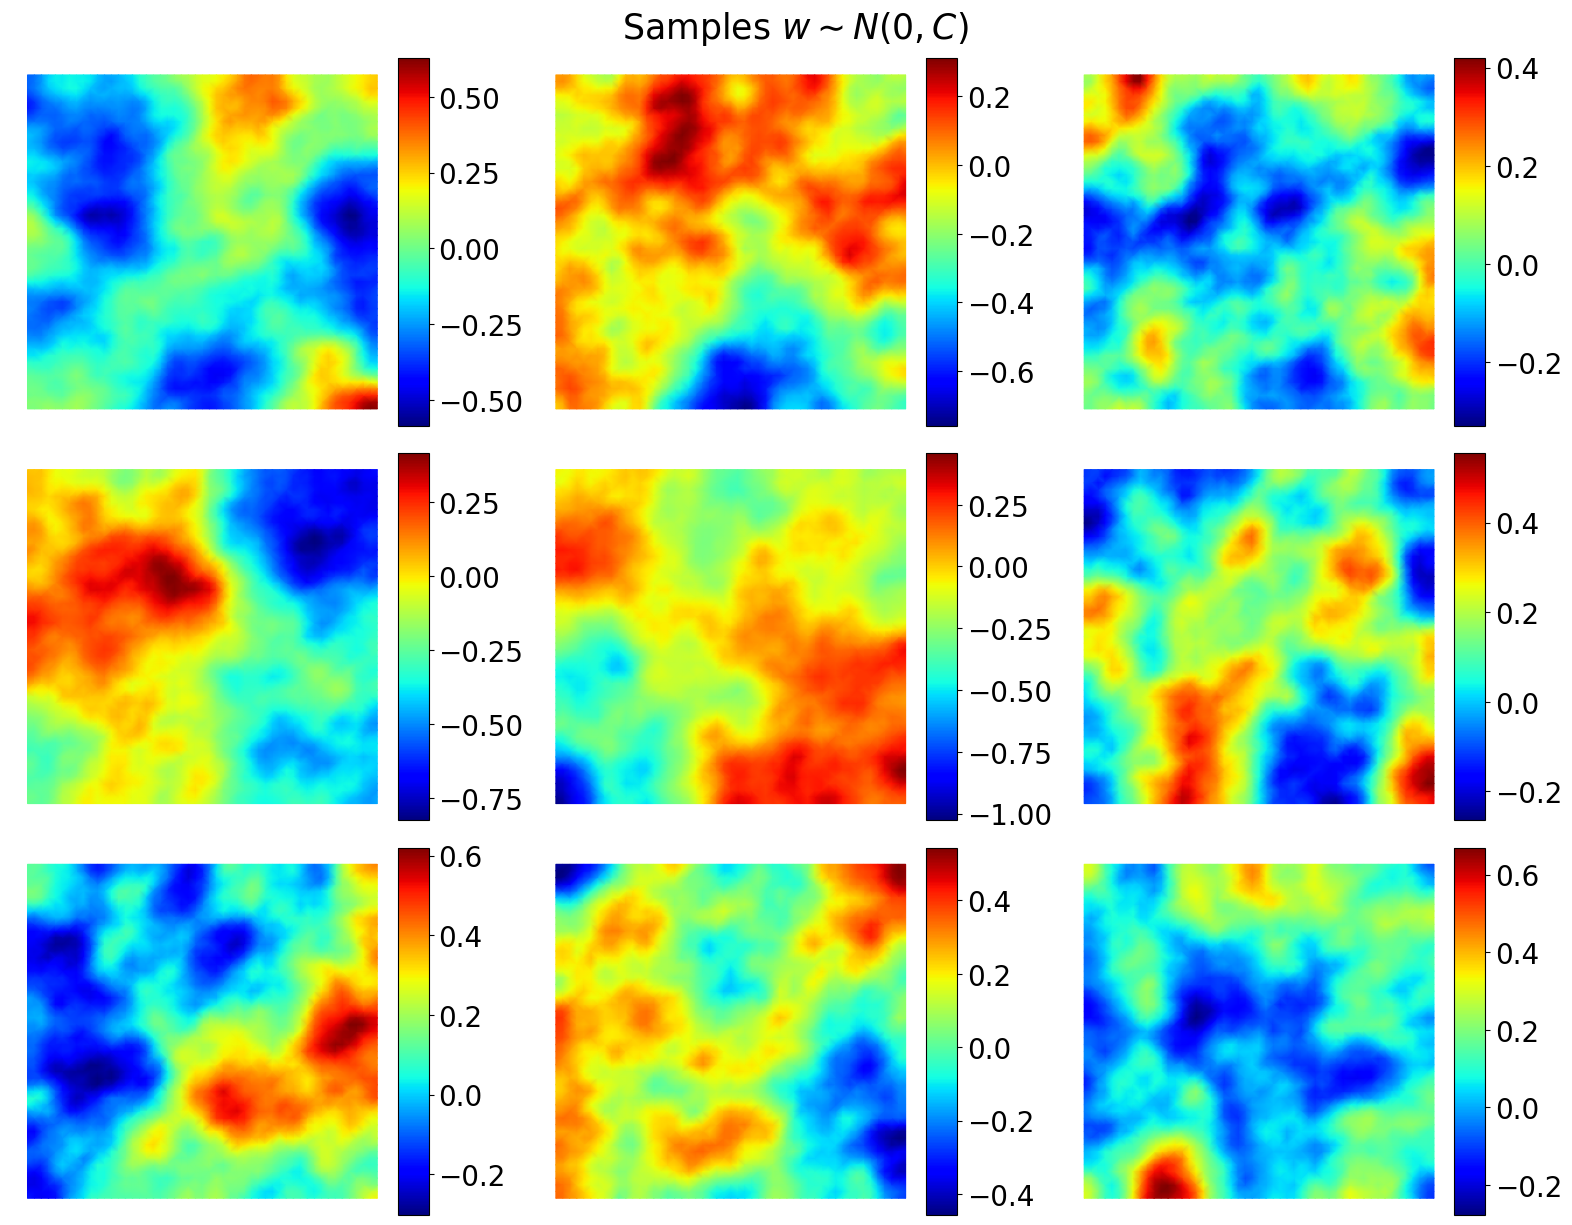

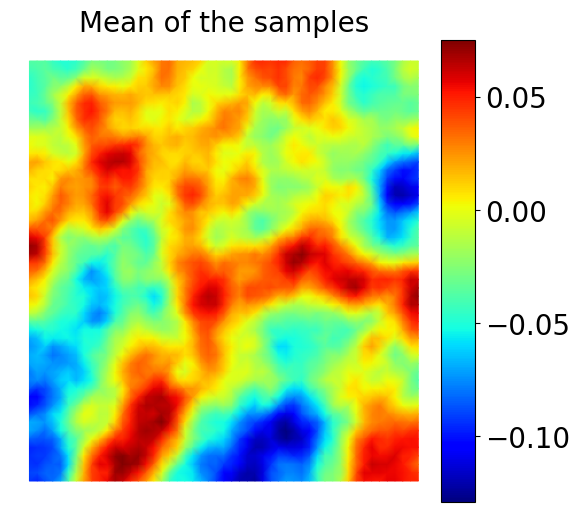

CPU times: user 1.25 s, sys: 1.35 s, total: 2.6 s
Wall time: 870 ms


In [5]:
%%time 

fs = 20
rows, cols = 3, 3
fig, axs = plt.subplots(rows, cols, figsize=(16, 12))
stats = []
mvec = []
print_info = False
m = model.prior_sampler.empty_sample()
for i in range(rows):
    for j in range(cols):
        # draw a sample
        m, log_prior = model.prior_sampler(m)

        mvec.append(m)
        stats.append([np.min(m), np.max(m), np.mean(m), np.std(m), log_prior])
        if print_info:
            print('Sample: {:2d}, log_prior = {:.2e}, min = {:.2e}, max = {:.2e}, mean = {:.2e}, std = {:.2e}'.format(i*cols + j, log_prior, np.min(m), np.max(m), np.mean(m), np.std(m)))

        # plot
        cbar = field_plot(axs[i,j], \
                  m, \
                  nodes, cmap = 'jet')
        divider = make_axes_locatable(axs[i,j])
        cax = divider.append_axes('right', size='8%', pad=0.03)
        cax.tick_params(labelsize=fs)
        cbar = fig.colorbar(cbar, cax=cax, orientation='vertical')
        axs[i,j].axis('off')

# satistics
stats = np.array(stats)
print('Statistics of all samples')
print('Mean: min = {:.2e}, max = {:.2e}, mean = {:.2e}, std = {:.2e}, log_prior = {:.2e}'.format(np.mean(stats[:,0]), np.mean(stats[:,1]), np.mean(stats[:,2]), np.mean(stats[:,3]), np.mean(stats[:,4])))

fig.tight_layout()
fig.suptitle(r'Samples $w\sim N(0,C)$', fontsize=1.25*fs, y = 1.025)
plt.savefig(results_dir + 'prior_samples.png',  bbox_inches='tight')
plt.show()

# compute mean sample field
mvec = np.array(mvec)
m = np.mean(mvec, axis=0)
quick_field_plot(m, nodes, title='Mean of the samples', cmap ='jet')


# Test LinearElasticity model

## Generate few samples of Youngs modulus and solve the forward problem

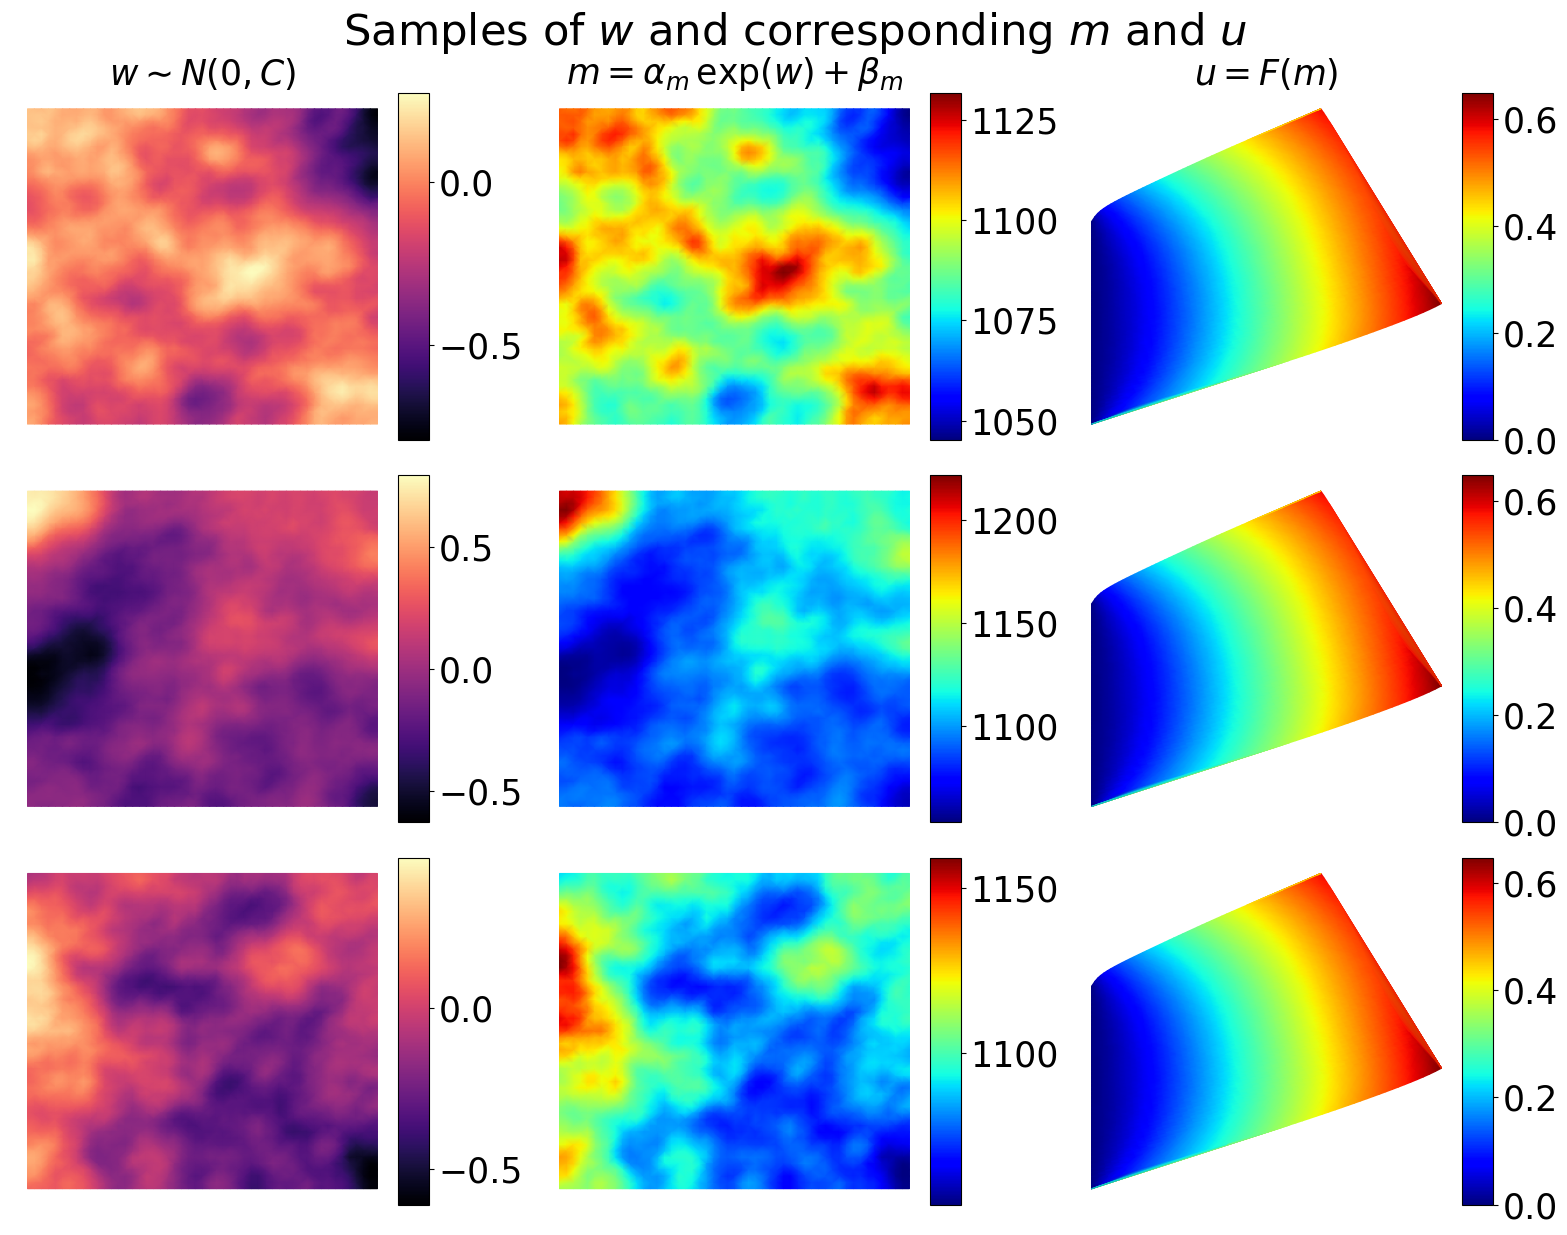

In [6]:
n_test_samples = 3

u_vec = []
title_vec = []
cmapvec = []
flag_is_vec = []
flag_add_disp = []
plot_type = []
for i in range(n_test_samples): 
    cmapvec.append(['magma', 'jet', 'jet'])
    if i == 0:
        title_vec.append([r'$w \sim N(0, C)$', r'$m = \alpha_m\, \exp(w) + \beta_m$', r'$u = F(m)$'])
    else:
        title_vec.append([None, None, None])
    
    flag_is_vec.append([False, False, True])
    flag_add_disp.append([False, False, True])
    plot_type.append(['field' for i in range(3)])

w = model.empty_m()
m = model.empty_m()
u = model.empty_u()

for i in range(n_test_samples):

    # draw a sample
    w, log_prior = model.prior_sampler(w)

    # transform w to m
    # m = model.m_mean
    m = model.transform_gaussian_pointwise(w, m)    
    
    # solve
    u = model.solveFwd(u, m, transform_m = False)

    ## ----------------- ##
    # fake displacement to test the plot (FEniCSx interleaved: u[2*k], u[2*k+1])
    if False:
        num_nodes = model.m_nodes.shape[0]
        for k in range(num_nodes):
            val = 0.1 * (i + 1) * np.linalg.norm(nodes[k])
            u[2 * k] = val
            u[2 * k + 1] = val
    ## ----------------- ##
    
    u_vec.append([w, m, u])

# plot all samples
plot_data = get_default_plot_mix_collection_data(rows = n_test_samples, \
    cols = 3, \
    nodes = model.m_nodes, \
    figsize = (16, 12), fs = 25, \
    sup_title = r'Samples of $w$ and corresponding $m$ and $u$', \
    y_sup_title = 1.025, \
    savefilename = None, \
    u = u_vec, cmap = cmapvec, title = title_vec, \
    is_vec = flag_is_vec, add_disp = flag_add_disp, \
    plot_type = plot_type)

plot_mix_collection(plot_data)


In [7]:
a = model.m_mean
print('stats of mean of m:', a.mean(), a.min(), a.max())
a = model.samplePrior(a, transform_m = True)
print('stats of sample of m:', a.mean(), a.min(), a.max())
a =  u_vec[-1]
print('stats of mean of u:', a[2].mean(), a[2].min(), a[2].max())

stats of mean of m: 1100.0 1100.0 1100.0
stats of sample of m: 1100.232094992612 1050.6329934372181 1138.647987740926
stats of mean of u: 0.14085071915204445 -0.17572117148140654 0.5947540051508117


## Locate the nodes on the Dirichlet boundary

In [8]:
u_mesh_dirichlet_boundary_nodes = get_dirichlet_bc(model.is_point_on_dirichlet_boundary, nodes)

print(u_mesh_dirichlet_boundary_nodes.shape, u_mesh_dirichlet_boundary_nodes)

# verify that the boundary nodes are correct
# FEniCSx P1 vector layout: [ux(v0), uy(v0), ux(v1), uy(v1), ...]
num_nodes = nodes.shape[0]
n_test_samples = 10

for i in range(n_test_samples):

    u = model.solveFwd(m = model.samplePrior(transform_m = True), transform_m = False)

    u_bc = u.reshape(num_nodes, 2)[u_mesh_dirichlet_boundary_nodes, :]
    bc_x_err = np.linalg.norm(u_bc[:, 0])
    bc_y_err = np.linalg.norm(u_bc[:, 1])
    print('bc_x_err = {:.2e}, bc_y_err = {:.2e}'.format(bc_x_err, bc_y_err))


(51,) [1324 1326 1376 1425 1473 1520 1566 1611 1655 1698 1740 1781 1821 1860
 1898 1935 1971 2006 2040 2073 2105 2136 2166 2195 2223 2250 2276 2301
 2325 2348 2370 2391 2411 2430 2448 2465 2481 2496 2510 2523 2535 2546
 2556 2565 2573 2580 2586 2591 2595 2598 2600]
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00
bc_x_err = 0.00e+00, bc_y_err = 0.00e+00


## Generate data

**Article reproduction:** set `generate_data = True` and `generate_fno_data = True` in the cells below (see `survey_work/ArticleResultsReproduction.md`). Defaults load existing `.npz` files.


In [9]:
generate_data = True
if generate_data:
    num_samples = 4000

    w_samples = np.zeros((num_samples, model.m_dim))
    m_samples = np.zeros((num_samples, model.m_dim))
    u_samples = np.zeros((num_samples, model.u_dim))

    w, m, u = model.empty_m(), model.empty_m(), model.empty_u()

    for i in range(num_samples):

        start_time = time.perf_counter()

        # draw from gaussian prior
        if i == 0:
            w = prior_sampler.mean.copy()
        else:
            w = prior_sampler(w)[0]
        
        # transform w to m
        m = model.transform_gaussian_pointwise(w, m)
        
        # if m is transformed above, we do not need to transform it again
        u = model.solveFwd(u, m, transform_m = False)

        # save
        w_samples[i, :] = w
        m_samples[i, :] = m
        u_samples[i, :] = u

        end_time = time.perf_counter()
        sample_time = end_time - start_time

        if i % 100 == 0:
            print('Sample {:4d} took {:.3f} seconds'.format(i, sample_time))

    print(w_samples.shape, m_samples.shape, u_samples.shape)


Sample    0 took 0.034 seconds
Sample  100 took 0.025 seconds
Sample  200 took 0.028 seconds
Sample  300 took 0.029 seconds
Sample  400 took 0.030 seconds
Sample  500 took 0.029 seconds
Sample  600 took 0.028 seconds
Sample  700 took 0.025 seconds
Sample  800 took 0.030 seconds
Sample  900 took 0.027 seconds
Sample 1000 took 0.028 seconds
Sample 1100 took 0.029 seconds
Sample 1200 took 0.026 seconds
Sample 1300 took 0.030 seconds
Sample 1400 took 0.029 seconds
Sample 1500 took 0.027 seconds
Sample 1600 took 0.026 seconds
Sample 1700 took 0.026 seconds
Sample 1800 took 0.029 seconds
Sample 1900 took 0.029 seconds
Sample 2000 took 0.026 seconds
Sample 2100 took 0.026 seconds
Sample 2200 took 0.028 seconds
Sample 2300 took 0.027 seconds
Sample 2400 took 0.026 seconds
Sample 2500 took 0.025 seconds
Sample 2600 took 0.026 seconds
Sample 2700 took 0.026 seconds
Sample 2800 took 0.025 seconds
Sample 2900 took 0.026 seconds
Sample 3000 took 0.028 seconds
Sample 3100 took 0.025 seconds
Sample 3

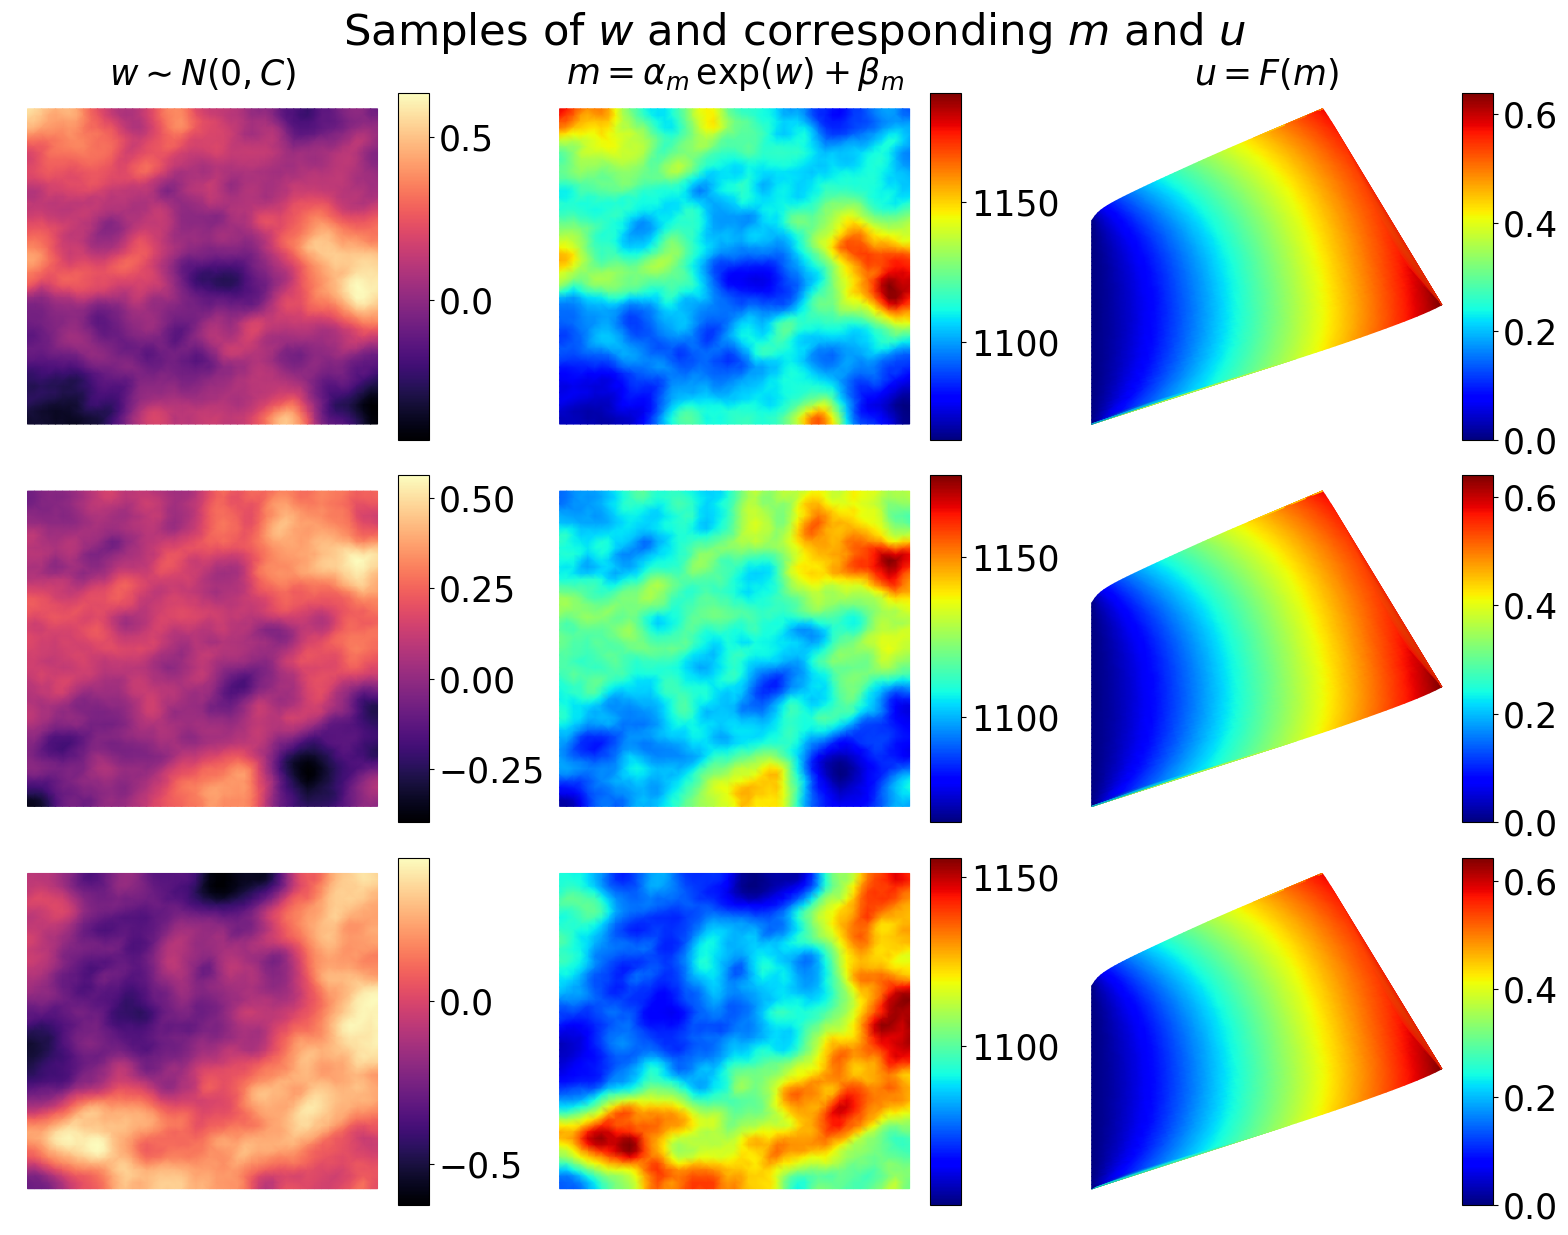

In [10]:
plot_from_data = True
if plot_from_data:
    if generate_data == False:
        data_load = np.load(results_dir + data_prefix + '_samples.npz')
        w_samples = data_load['w_samples']
        m_samples = data_load['m_samples']
        u_samples = data_load['u_samples']
    
    i_choices = np.random.choice(w_samples.shape[0], 3, replace=False)

    n_test_samples = len(i_choices)

    u_vec = []
    title_vec = []
    cmapvec = []
    flag_is_vec = []
    flag_add_disp = []
    plot_type = []
    for i in range(n_test_samples): 
        cmapvec.append(['magma', 'jet', 'jet'])
        if i == 0:
            title_vec.append([r'$w \sim N(0, C)$', r'$m = \alpha_m\, \exp(w) + \beta_m$', r'$u = F(m)$'])
        else:
            title_vec.append([None, None, None])
        
        flag_is_vec.append([False, False, True])
        flag_add_disp.append([False, False, True])
        plot_type.append(['field' for i in range(3)])

        ii = i_choices[i]
        u_vec.append([w_samples[ii, :], m_samples[ii, :], u_samples[ii, :]])


    # plot all samples
    plot_data = get_default_plot_mix_collection_data(rows = n_test_samples, \
        cols = 3, \
        nodes = model.m_nodes, \
        figsize = (16, 12), fs = 25, \
        sup_title = r'Samples of $w$ and corresponding $m$ and $u$', \
        y_sup_title = 1.025, \
        savefilename = results_dir + data_prefix + '_sample_plots.png', \
        u = u_vec, cmap = cmapvec, title = title_vec, \
        is_vec = flag_is_vec, add_disp = flag_add_disp, \
        plot_type = plot_type)

    plot_mix_collection(plot_data)


In [11]:
if True:
    # analyze SVD of the data
    proj_w_dim, proj_m_dim, proj_u_dim = 100, 100, 100
    tol = 1.e-9
    if generate_data is False:
        data = np.load(results_dir + data_prefix + '_samples.npz')
        w_samples = data['w_samples']
        m_samples = data['m_samples']
        u_samples = data['u_samples']
        w_SVD = data['w_SVD']
        m_SVD = data['m_SVD']
        u_SVD = data['u_SVD']
        w_s = data['w_s']
        m_s = data['m_s']
        u_s = data['u_s']
    else:
        w_mean = np.mean(w_samples, axis = 0)
        m_mean = np.mean(m_samples, axis = 0)
        u_mean = np.mean(u_samples, axis = 0)
        w_std = np.std(w_samples, axis = 0)
        m_std = np.std(m_samples, axis = 0)
        u_std = np.std(u_samples, axis = 0)
        w_normalized = (w_samples - w_mean) / (w_std + tol)
        m_normalized = (m_samples - m_mean) / (m_std + tol)
        u_normalized = (u_samples - u_mean) / (u_std + tol)
        w_SVD, w_s, _ = np.linalg.svd(w_normalized.T, full_matrices = False)
        m_SVD, m_s, _ = np.linalg.svd(m_normalized.T, full_matrices = False)
        u_SVD, u_s, _ = np.linalg.svd(u_normalized.T, full_matrices = False)


j = 0, i = 0, index = 100, index_val = 0.03215607516260292
j = 0, i = 1, index = 100, index_val = 0.032767742789025237
j = 0, i = 2, index = 100, index_val = 0.0016748261099481826
j = 1, i = 0, index = 34, index_val = 0.0999793197691851
j = 1, i = 1, index = 35, index_val = 0.1011051172766049
j = 1, i = 2, index = 6, index_val = 0.1052278079374545
j = 2, i = 0, index = 285, index_val = 0.009988216554316072
j = 2, i = 1, index = 290, index_val = 0.009981634503387217
j = 2, i = 2, index = 34, index_val = 0.009939804613539154


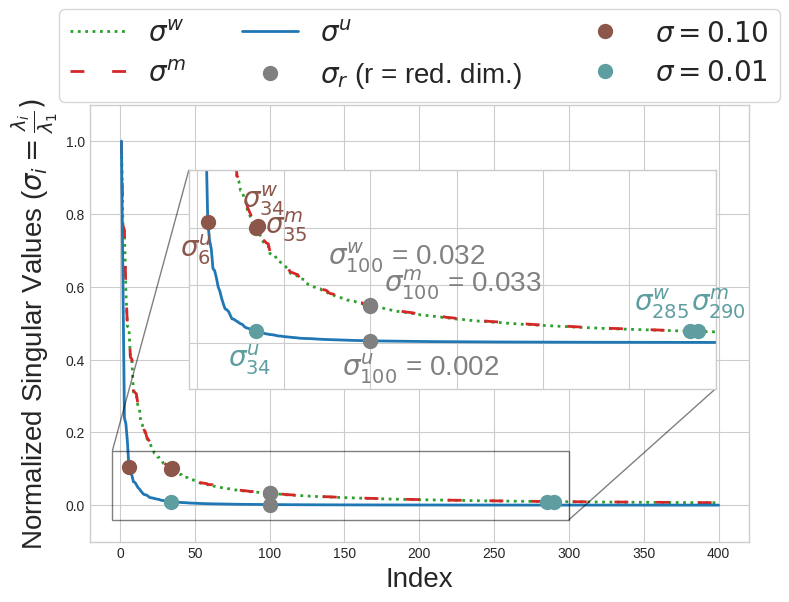

j = 0, i = 0, index = 100, index_val = 0.032767742789025237
j = 0, i = 1, index = 100, index_val = 0.0016748261099481826
j = 1, i = 0, index = 35, index_val = 0.1011051172766049
j = 1, i = 1, index = 6, index_val = 0.1052278079374545
j = 2, i = 0, index = 290, index_val = 0.009981634503387217
j = 2, i = 1, index = 34, index_val = 0.009939804613539154


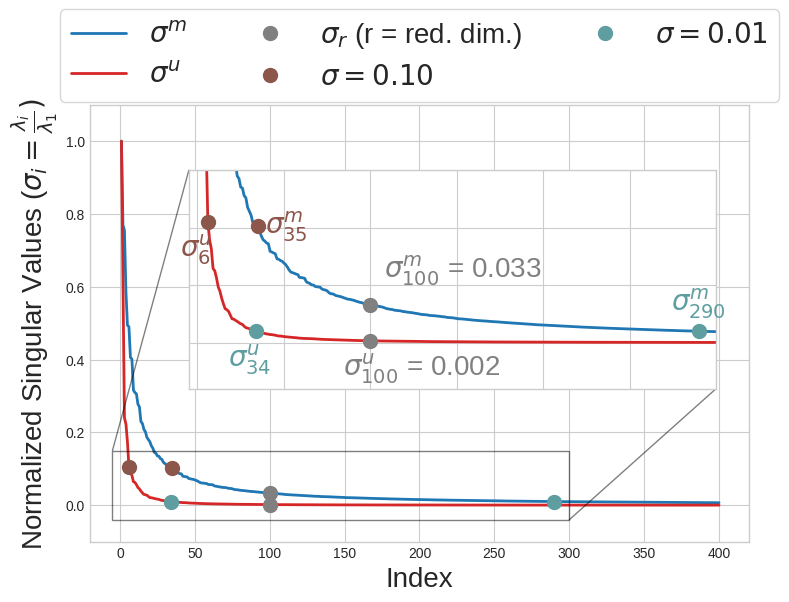

In [12]:
if True:
    plot_annot_xy = [0.15, 0.35, 0.8, 0.5]
    plot_annot_xy_region = [-5, 300, -0.04, 0.15]
    xy_text_vec = []
    xy_text_vec.append([(-30, 30), (10, 10), (-20, -25)])
    xy_text_vec.append([(-10, 15), (5, -5), (-20, -25)])
    xy_text_vec.append([(-40, 15), (-5, 15), (-20, -25)])
    l_style_vec = [':', (0, (5, 10)), '-', '.']

    plot_s_vec_values([w_s, m_s, u_s], [proj_w_dim, proj_m_dim, proj_u_dim], \
                      ['w', 'm', 'u'], \
                      l_style_vec, \
                      xy_text_vec, \
                      plot_annot_xy, \
                      plot_annot_xy_region, \
                      results_dir + data_prefix + '_svd_analysis_w_m_u')

    xy_text_vec = []
    xy_text_vec.append([(10, 20), (-20, -25)])
    xy_text_vec.append([(5, -5), (-20, -25)])
    xy_text_vec.append([(-20, 15), (-20, -25)])
    l_style_vec = ['-', '-']
    plot_s_vec_values([m_s, u_s], [proj_m_dim, proj_u_dim], \
                      ['m', 'u'], \
                      l_style_vec, \
                      xy_text_vec, \
                      plot_annot_xy, \
                      plot_annot_xy_region, \
                      results_dir + data_prefix + '_svd_analysis_m_u')


In [13]:
if generate_data:
    u_mesh_dirichlet_boundary_nodes = get_dirichlet_bc(model.is_point_on_dirichlet_boundary, nodes)

    mesh_connectivity = mesh_cells(model.mesh)

    # data to save
    np.savez(results_dir + data_prefix + '_samples.npz', \
            w_samples = w_samples, \
            m_samples = m_samples, \
            u_samples = u_samples, \
            num_samples = num_samples, \
            m_dim = model.m_dim, u_dim = model.u_dim, \
            fe_order = fe_order, \
            nx = nx, ny = ny, \
            prior_ac = prior_ac, \
            prior_cc = prior_cc, \
            prior_alpham = prior_logn_scale, \
            prior_betam = prior_logn_translate, \
            u_mesh_nodes = model.m_nodes, \
            m_mesh_nodes = model.m_nodes, \
            u_mesh_elements = mesh_connectivity, \
            m_mesh_elements = mesh_connectivity, \
            u_mesh_dirichlet_boundary_nodes = u_mesh_dirichlet_boundary_nodes, \
            w_SVD = w_SVD, w_s = w_s, \
            m_SVD = m_SVD, m_s = m_s, \
            u_SVD = u_SVD, u_s = u_s)


    # save mesh
    write_mesh_xdmf(model.mesh, results_dir + data_prefix + '_u_mesh.xdmf', MPI.COMM_WORLD)
    write_mesh_xdmf(model.mesh, results_dir + data_prefix + '_m_mesh.xdmf', MPI.COMM_WORLD)


In [14]:
print('m_mesh_nodes shape: {}\nu_mesh_nodes shape: {}\nm_dim: {}\nu_dim: {}'.format(nodes.shape, nodes.shape, model.m_dim, model.u_dim))

m_mesh_nodes shape: (2601, 2)
u_mesh_nodes shape: (2601, 2)
m_dim: 2601
u_dim: 5202


## Interpolate function at nodal values to meshgrid for FNO

FNO grid vector data uses the same **mixed (FEniCSx) layout** as mesh data:
- mesh `u`: `[ux(v0), uy(v0), ux(v1), uy(v1), ...]`
- grid `grid_u` shape `(nx, ny, 2)`: `grid_u[i, j, :] = [ux, uy]` at grid point `(i, j)`
- flat mixed: `grid_u.reshape(-1)` gives `[ux0, uy0, ux1, uy1, ...]`

### Compute and plot interpolation over grid

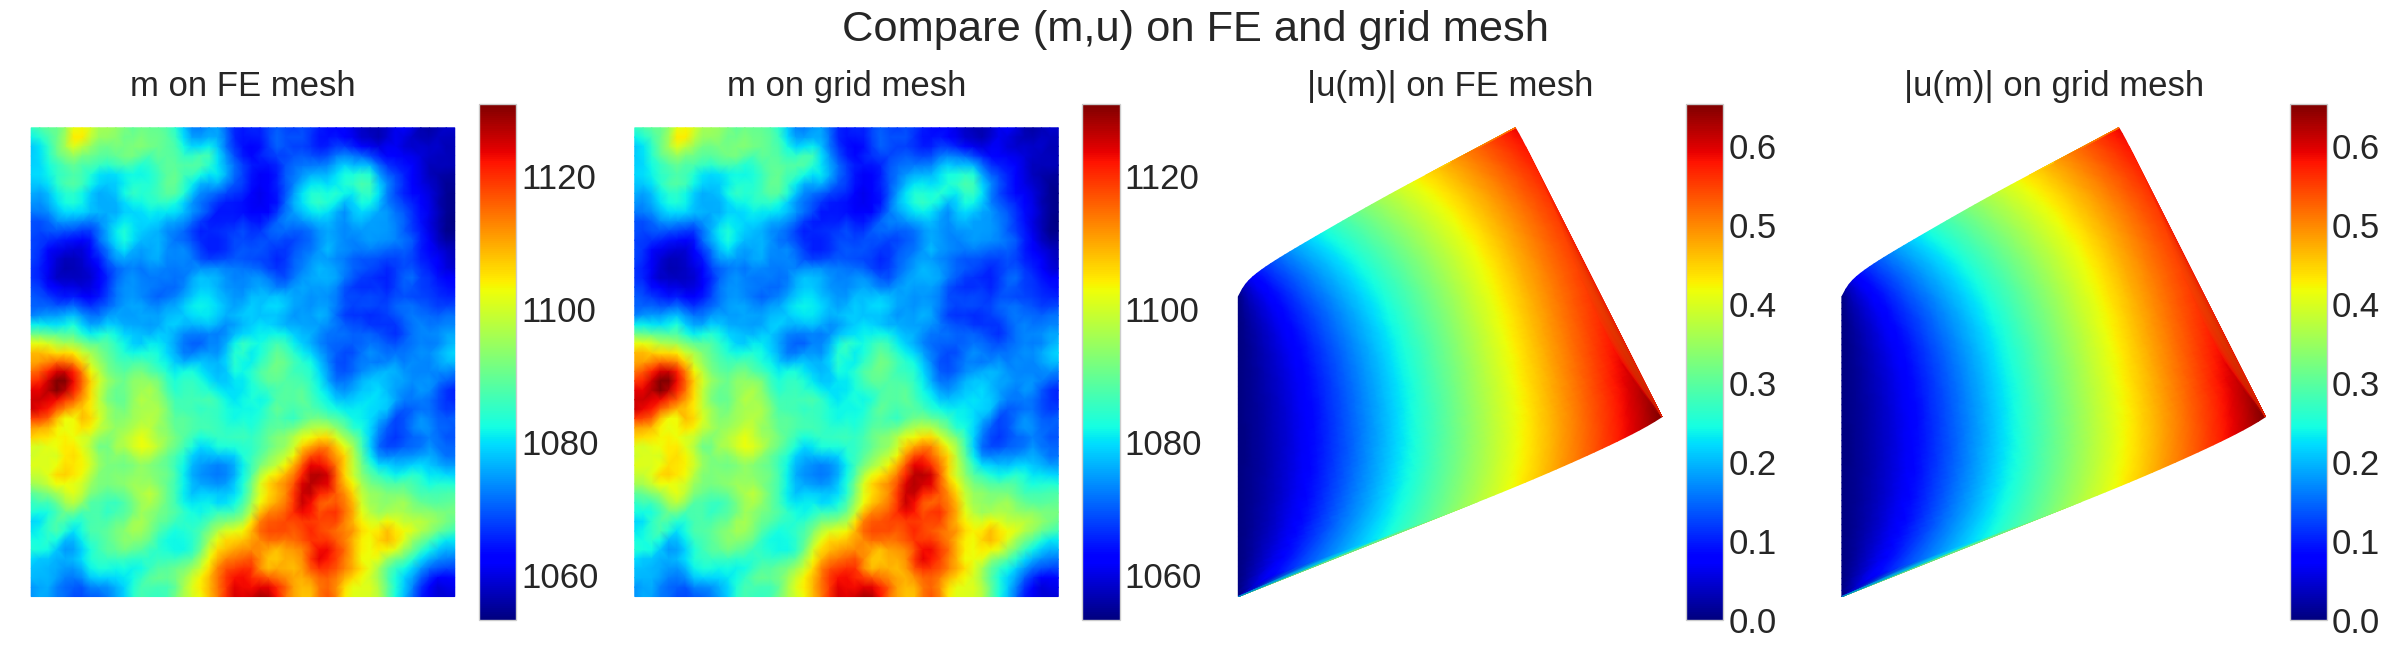

In [15]:
data_load = np.load(results_dir + data_prefix + '_samples.npz')
u_nodes = data_load['u_mesh_nodes']
m_nodes = data_load['m_mesh_nodes']
num_nodes = u_nodes.shape[0]

# get one sample
m = model.samplePrior(transform_m = True)
u = model.solveFwd(u = None, m = m, transform_m = False)

# use interpolation to get data on grid
num_grid_x, num_grid_y = 51, 51
grid_x, grid_y = np.meshgrid(np.linspace(0, 1, num_grid_x), np.linspace(0, 1, num_grid_y), indexing='ij')

# interpolate m and mixed mesh vector u on grid -> grid_u shape (nx, ny, 2)
grid_m = griddata(m_nodes, m, (grid_x, grid_y), method='linear')
grid_u = interpolate_mixed_vector_to_grid(u_nodes, u, grid_x, grid_y)

# plot function on FE mesh and compare with the function on grid

rows = 1
cols = 4
fs = 25
fig, axs = plt.subplots(rows, cols, figsize=(24, 6))

for i in range(cols):
    
    if i%2 == 0:
        # use plotter without element data
        if i == 0:
            cbar = field_plot(axs[i], m, m_nodes, cmap = 'jet')
            axs[i].set_title('m on FE mesh', fontsize = fs)
        else:
            cbar = field_plot(axs[i], \
                        u, \
                        u_nodes, \
                        cmap = 'jet', \
                        add_displacement_to_nodes = True, \
                        is_displacement = True)
            axs[i].set_title('|u(m)| on FE mesh', fontsize = fs)
    else:
        # use griddata
        if i == 1:
            cbar = field_plot_grid(axs[i], grid_m, grid_x, grid_y, cmap = 'jet')
            axs[i].set_title('m on grid mesh', fontsize = fs)
        else:
            cbar = field_plot_grid(axs[i],\
                        grid_u, \
                        grid_x, \
                        grid_y, \
                        cmap = 'jet', \
                        add_displacement_to_nodes = True, \
                        is_displacement = True)
            axs[i].set_title('|u(m)| on grid mesh', fontsize = fs)

    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes('right', size='8%', pad=0.03)
    cax.tick_params(labelsize=fs)

    if i < 2:
        # format cbar ticks
        kfmt = lambda x, pos: "{:g}".format(x)
        
        cbar = fig.colorbar(cbar, cax=cax, orientation='vertical', format = kfmt)
    else:
        cbar = fig.colorbar(cbar, cax=cax, orientation='vertical')

    axs[i].axis('off')

fig.tight_layout()
fig.suptitle('Compare (m,u) on FE and grid mesh', fontsize=1.25*fs, y=1.075)
fig.savefig(results_dir + data_prefix + '_compare_FE_and_grid_mesh.png',  bbox_inches='tight')
plt.show()


### Interpolate all samples to grid and save to file for FNO

In [16]:
# save all samples to file
generate_fno_data = True
if generate_fno_data:

    num_grid_x, num_grid_y = 51, 51
    print('Generating FNO data for grid sizes ({}, {})'.format(num_grid_x, num_grid_y))

    # get grid coordinates
    grid_x, grid_y = np.meshgrid(np.linspace(0, 1, num_grid_x), np.linspace(0, 1, num_grid_y), indexing='ij')

    # load data
    data_load = np.load(results_dir + data_prefix + '_samples.npz')
    
    m_nodes = data_load['m_mesh_nodes']
    u_nodes = data_load['u_mesh_nodes']
    num_nodes = u_nodes.shape[0]

    w_samples = data_load['w_samples']
    m_samples = data_load['m_samples']
    u_samples = data_load['u_samples']

    num_samples = m_samples.shape[0]

    # get indices of grid points on the boundary
    u_grid_dirichlet_boundary_nodes = get_grid_dirichlet_bc(model.is_point_on_dirichlet_boundary, grid_x, grid_y)
    
    # interpolate samples on grid (mixed vector layout for grid_u)
    grid_w_samples = np.zeros((num_samples, num_grid_x, num_grid_y))
    grid_m_samples = np.zeros((num_samples, num_grid_x, num_grid_y))
    grid_u_samples = np.zeros((num_samples, num_grid_x, num_grid_y, 2))
    for i in range(num_samples):
        start_time = time.perf_counter()
        
        grid_w_samples[i, :, :] = griddata(m_nodes, w_samples[i, :], (grid_x, grid_y), method='linear')
        grid_m_samples[i, :, :] = griddata(m_nodes, m_samples[i, :], (grid_x, grid_y), method='linear')
        grid_u_samples[i, :, :, :] = interpolate_mixed_vector_to_grid(
            u_nodes, u_samples[i, :], grid_x, grid_y
        )

        # explicitly set boundary points to zero (not necessary as the solution of PDE is zero on the boundary)
        apply_grid_vector_dirichlet_bc(
            grid_u_samples[i, :, :, :], u_grid_dirichlet_boundary_nodes, value=0.0
        )

        end_time = time.perf_counter()
        sample_time = end_time - start_time

        if i % 100 == 0:
            print('Sample {:4d} took {:.3f} seconds'.format(i, sample_time))

    print(grid_m_samples.shape, grid_u_samples.shape)


Generating FNO data for grid sizes (51, 51)
Sample    0 took 0.753 seconds
Sample  100 took 0.629 seconds
Sample  200 took 0.632 seconds
Sample  300 took 0.640 seconds
Sample  400 took 0.658 seconds
Sample  500 took 0.656 seconds
Sample  600 took 0.726 seconds
Sample  700 took 1.030 seconds
Sample  800 took 0.661 seconds
Sample  900 took 0.697 seconds
Sample 1000 took 0.646 seconds
Sample 1100 took 0.709 seconds
Sample 1200 took 0.759 seconds
Sample 1300 took 0.698 seconds
Sample 1400 took 0.648 seconds
Sample 1500 took 0.741 seconds
Sample 1600 took 0.630 seconds
Sample 1700 took 0.625 seconds
Sample 1800 took 0.729 seconds
Sample 1900 took 0.639 seconds
Sample 2000 took 0.657 seconds
Sample 2100 took 0.688 seconds
Sample 2200 took 0.701 seconds
Sample 2300 took 0.633 seconds
Sample 2400 took 0.661 seconds
Sample 2500 took 0.680 seconds
Sample 2600 took 0.631 seconds
Sample 2700 took 0.663 seconds
Sample 2800 took 0.628 seconds
Sample 2900 took 0.633 seconds
Sample 3000 took 0.631 sec

grid_u_samples shape: (4000, 51, 51, 2)


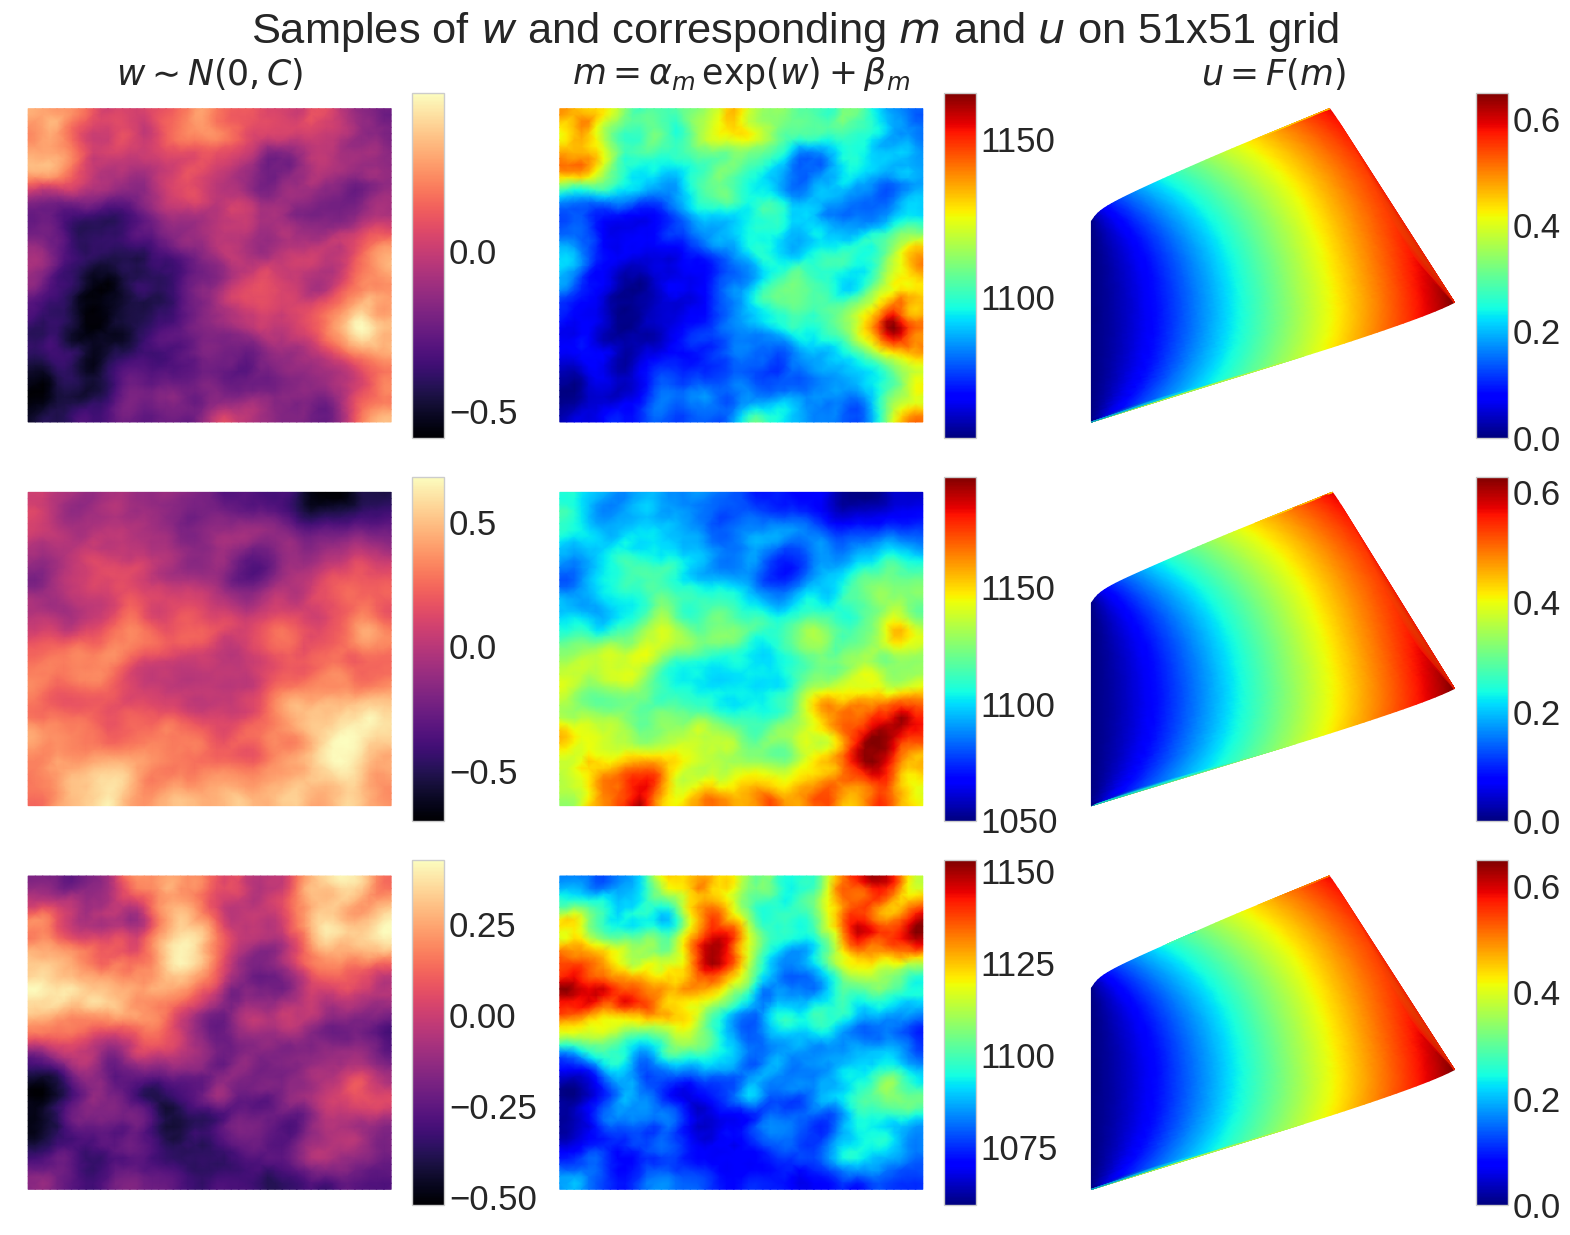

In [17]:
plot_from_data = True
if plot_from_data:
    if generate_fno_data == False:
        data_load = np.load(results_dir + data_prefix + '_FNO_samples.npz')
        grid_w_samples = data_load['grid_w_samples']
        grid_m_samples = data_load['grid_m_samples']
        grid_u_samples = data_load['grid_u_samples']
        grid_x = data_load['grid_x']
        grid_y = data_load['grid_y']
        num_grid_x = grid_x.shape[0]
        num_grid_y = grid_y.shape[1]
        num_fno_samples = grid_w_samples.shape[0]
    else:
        num_fno_samples = num_samples
    
    i_choices = np.random.choice(num_fno_samples, 3, replace=False)

    n_test_samples = len(i_choices)

    print('grid_u_samples shape:', grid_u_samples.shape)  

    u_vec = []
    title_vec = []
    cmapvec = []
    flag_is_vec = []
    flag_add_disp = []
    plot_type = []
    for i in range(n_test_samples): 
        cmapvec.append(['magma', 'jet', 'jet'])
        if i == 0:
            title_vec.append([r'$w \sim N(0, C)$', r'$m = \alpha_m\, \exp(w) + \beta_m$', r'$u = F(m)$'])
        else:
            title_vec.append([None, None, None])
        
        flag_is_vec.append([False, False, True])
        flag_add_disp.append([False, False, True])
        plot_type.append(['grid' for i in range(3)])

        ii = i_choices[i]
        u_vec.append([grid_w_samples[ii], grid_m_samples[ii], grid_u_samples[ii]])


    # plot all samples
    plot_data = get_default_plot_mix_collection_data(rows = n_test_samples, \
        cols = 3, \
        nodes = None, \
        grid_x = grid_x, \
        grid_y = grid_y, \
        figsize = (16, 12), fs = 25, \
        sup_title = r'Samples of $w$ and corresponding $m$ and $u$ on {}x{} grid'.format(num_grid_x, num_grid_y), \
        y_sup_title = 1.025, \
        savefilename = results_dir + data_prefix + '_sample_plots_on_grid.png', \
        u = u_vec, cmap = cmapvec, title = title_vec, \
        is_vec = flag_is_vec, add_disp = flag_add_disp, \
        plot_type = plot_type)

    plot_mix_collection(plot_data)


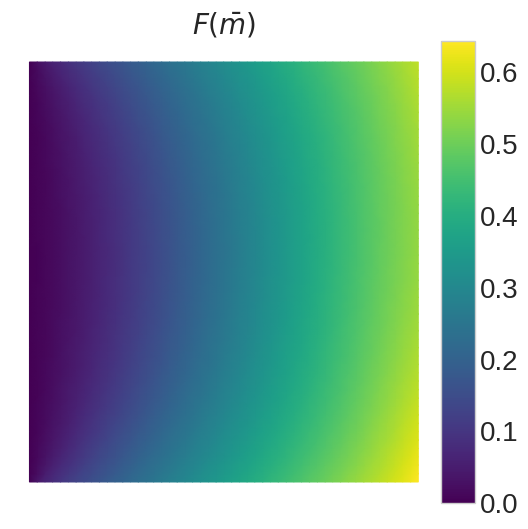

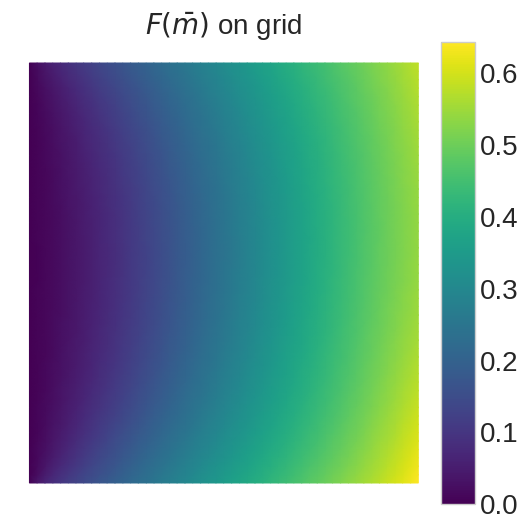

In [18]:
u_mean = model.solveFwd(u = None, m = model.m_mean, transform_m = False)
quick_field_plot(u_mean, nodes, title=r'$F(\bar{m})$', cmap ='viridis', is_displacement=True)

grid_u_mean = interpolate_mixed_vector_to_grid(u_nodes, u_mean, grid_x, grid_y)
quick_field_plot_grid(grid_u_mean, grid_x, grid_y, title=r'$F(\bar{m})$ on grid', cmap ='viridis', is_displacement=True)


In [19]:
# data to save
if generate_fno_data:
        np.savez(results_dir + data_prefix + '_FNO_samples.npz', \
                grid_w_samples = grid_w_samples, \
                grid_m_samples = grid_m_samples, \
                grid_u_samples = grid_u_samples, \
                num_samples = num_samples, \
                num_grid_x = num_grid_x, num_grid_y = num_grid_y, \
                grid_x = grid_x, grid_y = grid_y, \
                u_grid_dirichlet_boundary_nodes = u_grid_dirichlet_boundary_nodes, \
                u_vector_layout = 'mixed')


### Load data to test

In [20]:
data_load = np.load(results_dir + data_prefix + '_samples.npz')

print('num_samples: {}\nm_samples shape: {}\nu_samples shape: {}\nm_dim: {}\nu_dim: {}'.format(data_load['num_samples'], data_load['m_samples'].shape, data_load['u_samples'].shape, data_load['m_dim'], data_load['u_dim']))


num_samples: 4000
m_samples shape: (4000, 2601)
u_samples shape: (4000, 5202)
m_dim: 2601
u_dim: 5202


In [21]:
fno_data_load = np.load(results_dir + data_prefix + '_FNO_samples.npz')
print('num_samples: {}\ngrid_m_samples shape: {}\ngrid_u_samples shape: {}'.format(fno_data_load['num_samples'], fno_data_load['grid_m_samples'].shape, fno_data_load['grid_u_samples'].shape))


num_samples: 4000
grid_m_samples shape: (4000, 51, 51)
grid_u_samples shape: (4000, 51, 51, 2)
